In [1]:
import numpy as np
import fhrr_driver_torch as fd
import torch

In [2]:
data_sources = {
    "training_images": "train-images-idx3-ubyte.gz",  # 60,000 training images.
    "test_images": "t10k-images-idx3-ubyte.gz",  # 10,000 test images.
    "training_labels": "train-labels-idx1-ubyte.gz",  # 60,000 training labels.
    "test_labels": "t10k-labels-idx1-ubyte.gz",  # 10,000 test labels.
}

In [3]:
import requests
import os

data_dir = "../_data"
os.makedirs(data_dir, exist_ok=True)

base_url = "https://ossci-datasets.s3.amazonaws.com/mnist/"

for fname in data_sources.values():
    fpath = os.path.join(data_dir, fname)
    if not os.path.exists(fpath):
        print("Downloading file: " + fname)
        resp = requests.get(base_url + fname, stream=True)
        resp.raise_for_status()  # Ensure download was succesful
        with open(fpath, "wb") as fh:
            for chunk in resp.iter_content(chunk_size=128):
                fh.write(chunk)

In [4]:
import gzip
import numpy as np

mnist_dataset = {}

# Images
for key in ("training_images", "test_images"):
    with gzip.open(os.path.join(data_dir, data_sources[key]), "rb") as mnist_file:
        mnist_dataset[key] = np.frombuffer(
            mnist_file.read(), np.uint8, offset=16
        ).reshape(-1, 28 * 28)
# Labels
for key in ("training_labels", "test_labels"):
    with gzip.open(os.path.join(data_dir, data_sources[key]), "rb") as mnist_file:
        mnist_dataset[key] = np.frombuffer(mnist_file.read(), np.uint8, offset=8)

In [5]:
x_train, y_train, x_test, y_test = (
    mnist_dataset["training_images"],
    mnist_dataset["training_labels"],
    mnist_dataset["test_images"],
    mnist_dataset["test_labels"],
)

In [6]:
print(
    "The shape of training images: {} and training labels: {}".format(
        x_train.shape, y_train.shape
    )
)
print(
    "The shape of test images: {} and test labels: {}".format(
        x_test.shape, y_test.shape
    )
)

The shape of training images: (60000, 784) and training labels: (60000,)
The shape of test images: (10000, 784) and test labels: (10000,)


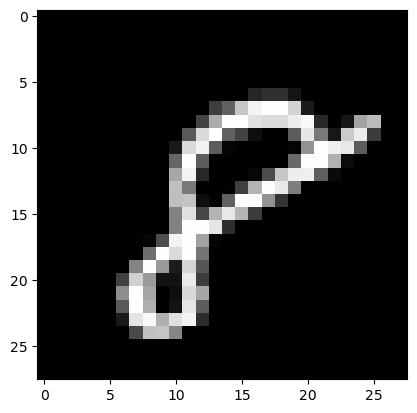

In [7]:
import matplotlib.pyplot as plt

# Take the 60,000th image (indexed at 59,999) from the training set,
# reshape from (784, ) to (28, 28) to have a valid shape for displaying purposes.
mnist_image = x_train[59999, :].reshape(28, 28)
# Set the color mapping to grayscale to have a black background.
plt.imshow(mnist_image, cmap="gray")
# Display the image.
plt.show()

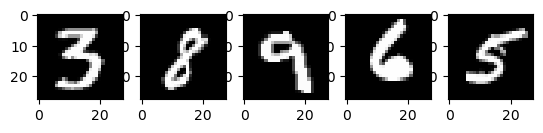

In [8]:
# Display 5 random images from the training set.
num_examples = 5
seed = 147197952744
rng = np.random.default_rng(seed)

fig, axes = plt.subplots(1, num_examples)
for sample, ax in zip(rng.choice(x_train, size=num_examples, replace=False), axes):
    ax.imshow(sample.reshape(28, 28), cmap="gray")

In [9]:
print("The data type of training images: {}".format(x_train.dtype))
print("The data type of test images: {}".format(x_test.dtype))

The data type of training images: uint8
The data type of test images: uint8


In [10]:
training_sample, test_sample = 1000, 1000
training_images = (x_train[0:training_sample] / 255).reshape(-1, 28, 28)[:,::2,::2].reshape(-1, 14*14)
test_images = x_test[0:test_sample] / 255

In [11]:
print("The data type of training images: {}".format(training_images.dtype))
print("The data type of test images: {}".format(test_images.dtype))

The data type of training images: float64
The data type of test images: float64


In [12]:
def one_hot_encoding(labels, dimension=10):
    # Define a one-hot variable for an all-zero vector
    # with 10 dimensions (number labels from 0 to 9).
    one_hot_labels = labels[..., None] == np.arange(dimension)[None]
    # Return one-hot encoded labels.
    return one_hot_labels.astype(np.float64)

In [13]:
training_labels = one_hot_encoding(y_train[:training_sample])
test_labels = one_hot_encoding(y_test[:test_sample])

In [14]:
training_images_flipped = 1 - training_images
training_images_both = np.concat([training_images, training_images_flipped], axis=1).transpose()
print(training_images_both.shape)

(392, 1000)


In [15]:
I_space = fd.fhrr_space(392)
P_space = fd.fhrr_space(2000)
E_space = fd.fhrr_space(1000)
M_space = fd.fhrr_space(100000)
IP_map = fd.fhrr_map(I_space, P_space)
PM_map = fd.fhrr_map(P_space, M_space)
EM_map = fd.fhrr_map(E_space, M_space)

In [16]:
def show_image(vec):
    return (vec[:392//2]/(vec[:392//2] + vec[392//2:])).reshape(14, 14)

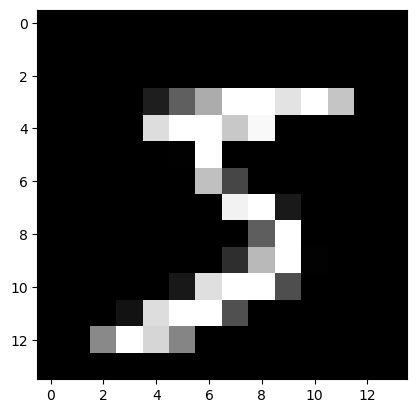

In [17]:
mnist_image = show_image(training_images_both.transpose()[0])
# Set the color mapping to grayscale to have a black background.
plt.imshow(mnist_image, cmap="gray")
# Display the image.
plt.show()

In [18]:
P_vecs = IP_map.forwards_norm(training_images_both.astype(np.complex64))
I_vecs = IP_map.backwards(P_vecs)


/tmp/ipykernel_188809/3777115032.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  I_vecs_r = np.abs(I_vecs)


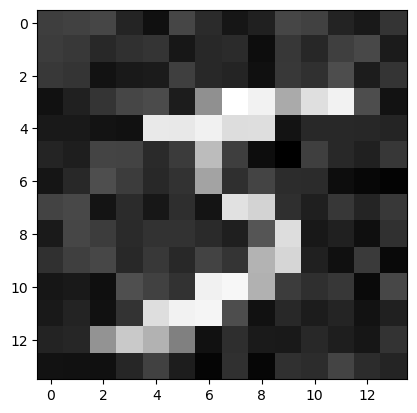

In [19]:
I_vecs_r = np.abs(I_vecs)
mnist_image = show_image(I_vecs_r.T[0])
# Set the color mapping to grayscale to have a black background.
plt.imshow(mnist_image, cmap="gray")
# Display the image.
plt.show()

In [20]:
M_bundle = M_space.bind_and_bundle([[PM_map.norm_forwards_norm(P_vecs[:, i:i+1]), EM_map.norm_forwards_norm(E_space.init_random_vec())]for i in range(10)])

/tmp/ipykernel_188809/1660316540.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  I_vec_r = np.abs(I_vec)


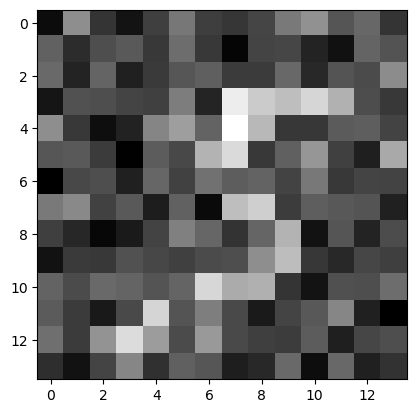

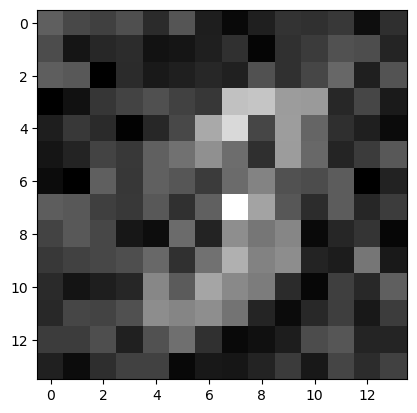

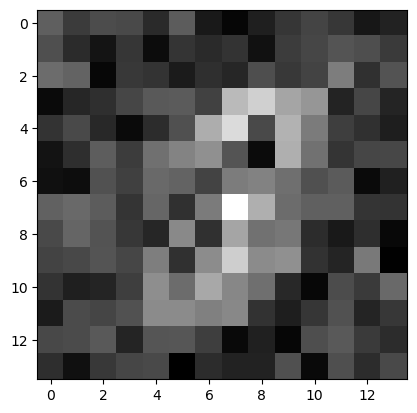

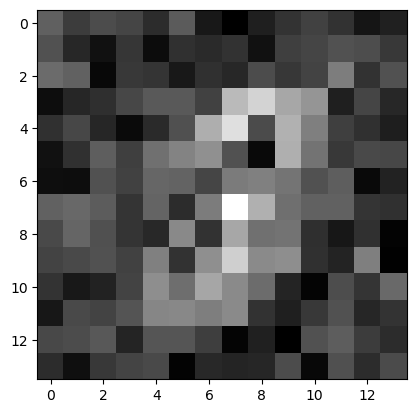

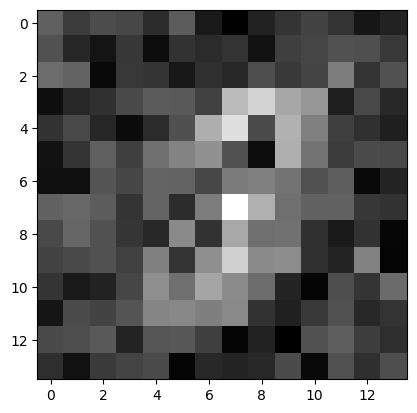

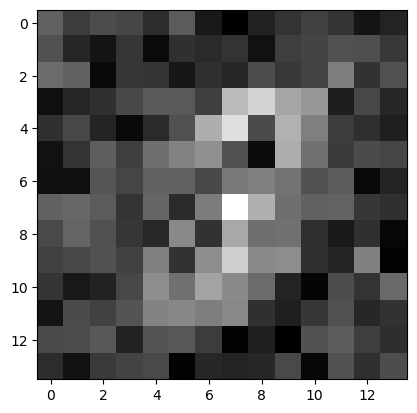

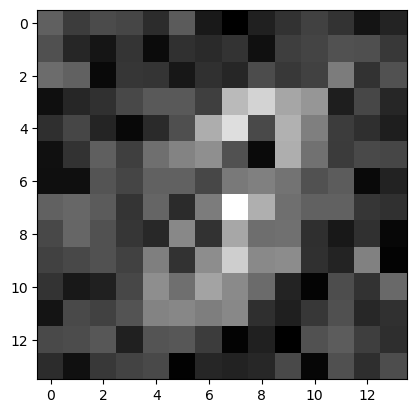

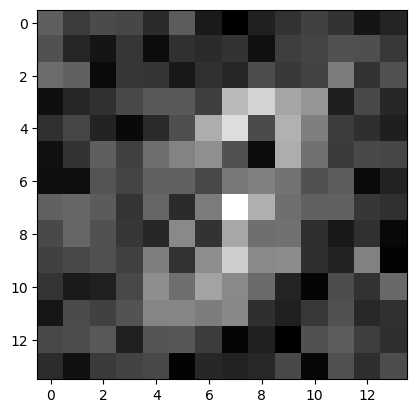

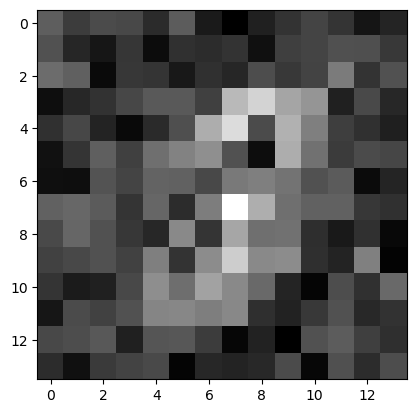

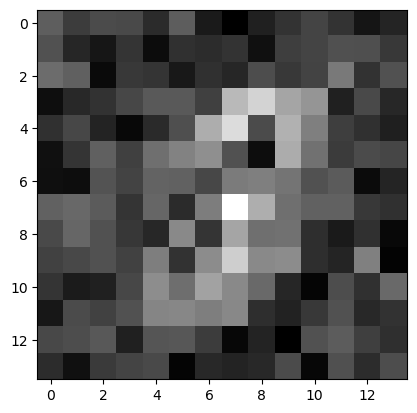

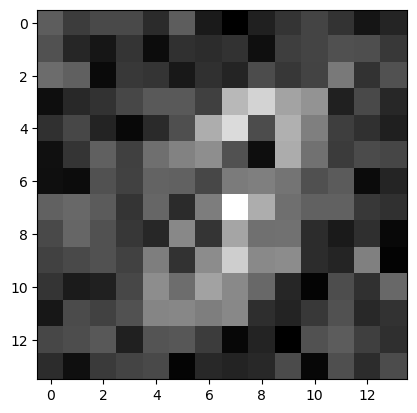

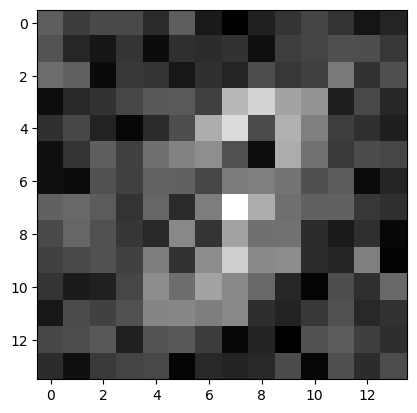

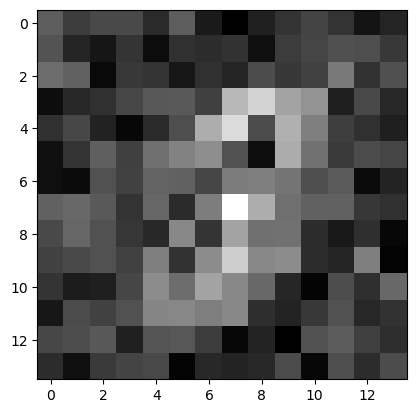

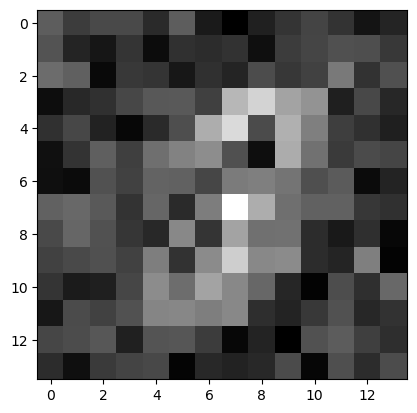

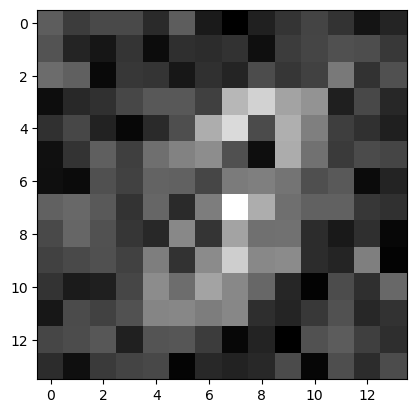

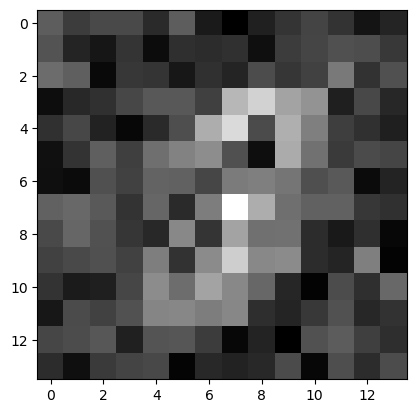

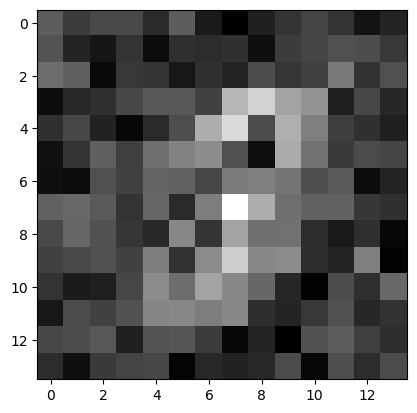

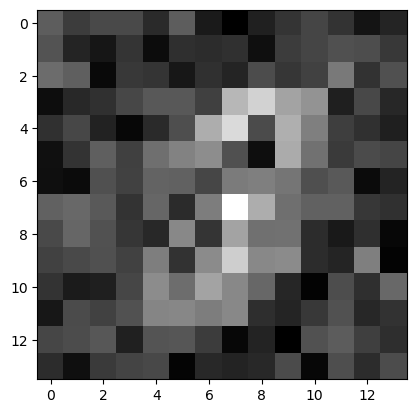

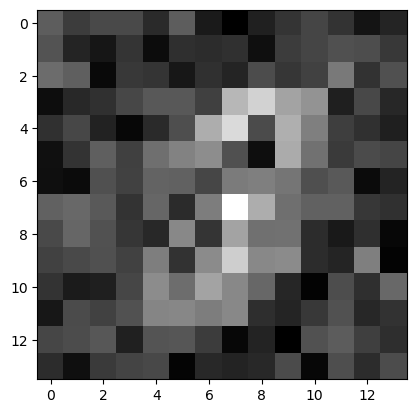

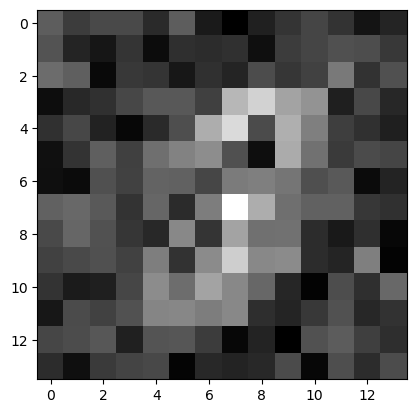

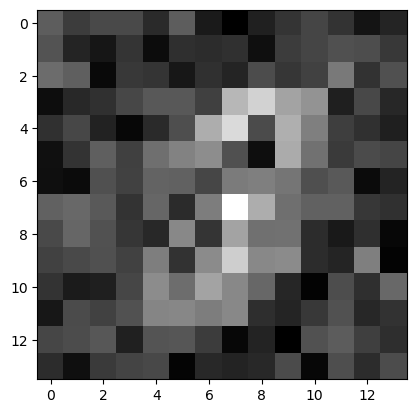

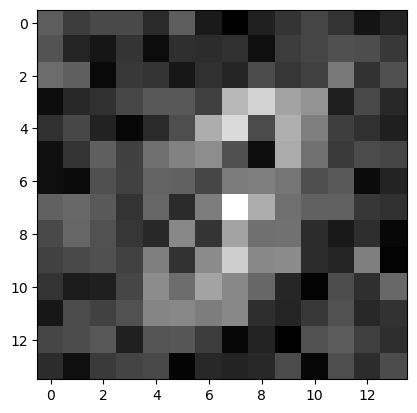

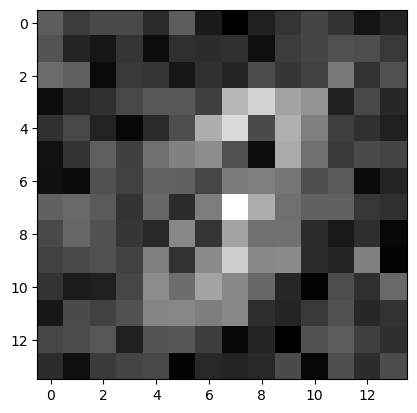

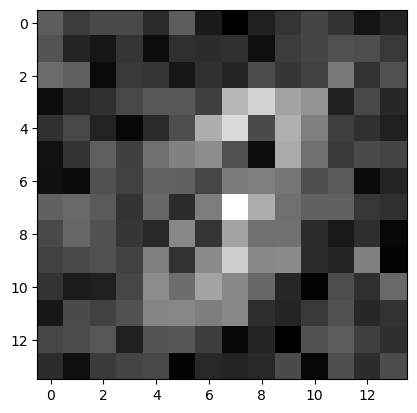

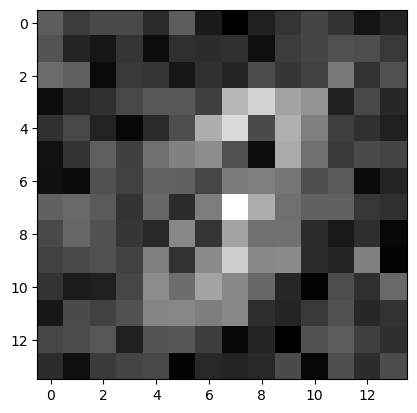

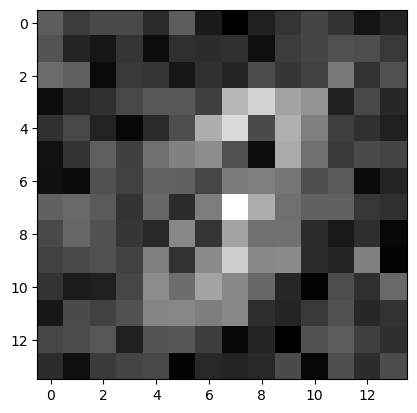

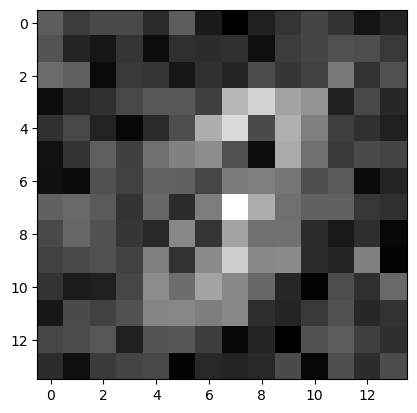

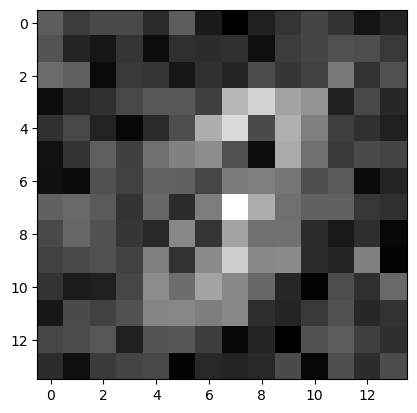

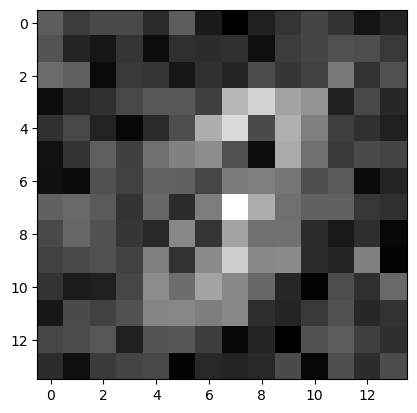

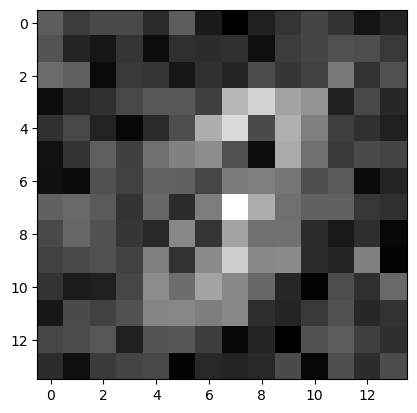

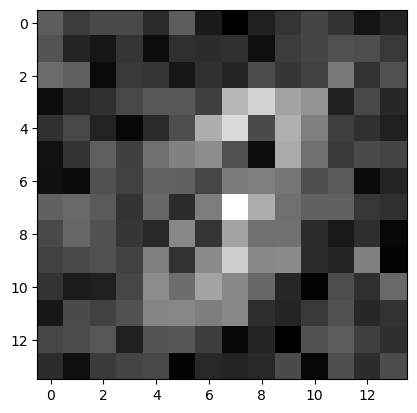

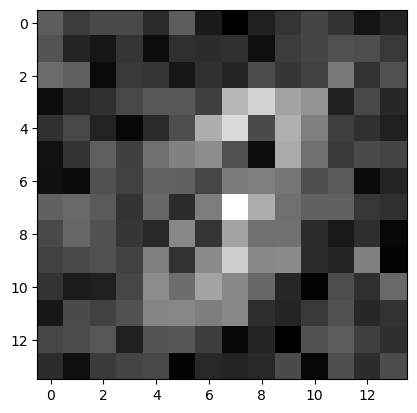

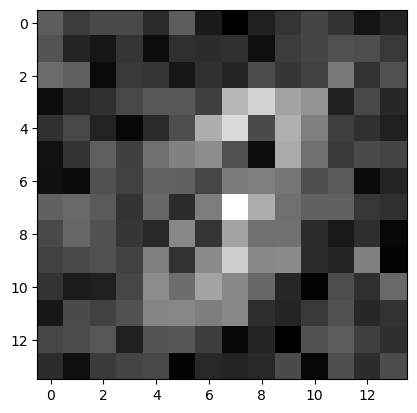

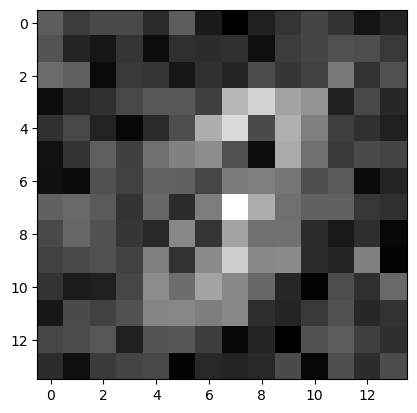

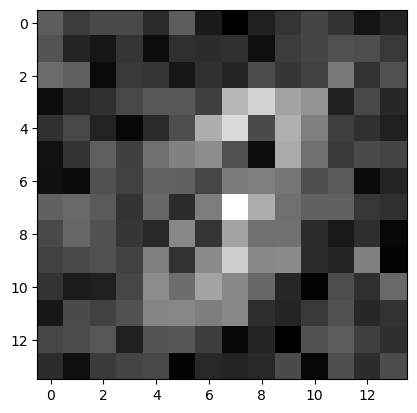

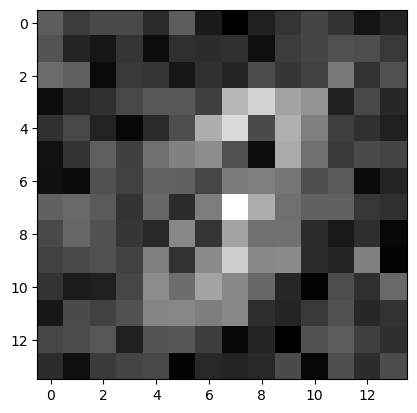

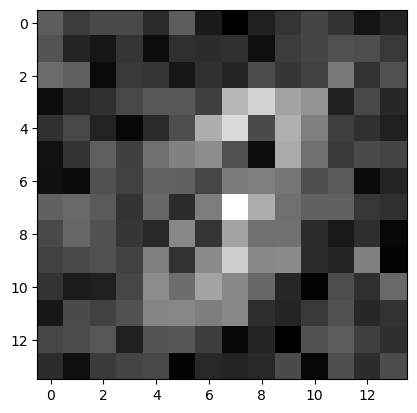

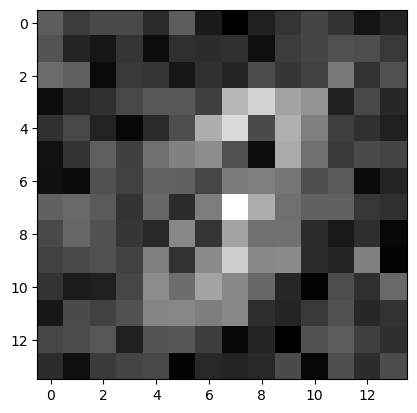

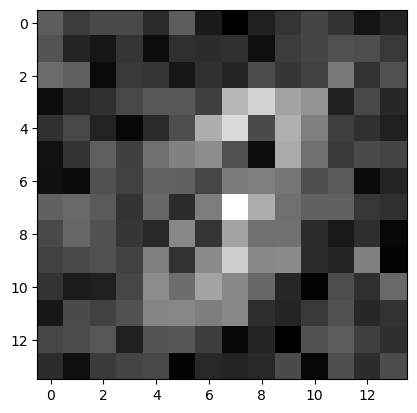

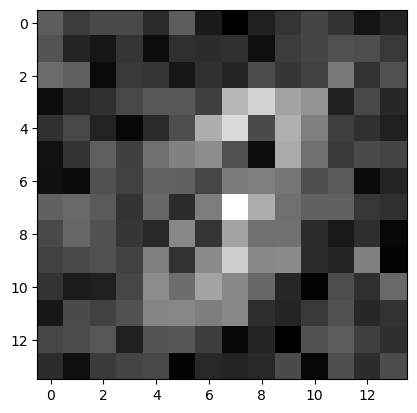

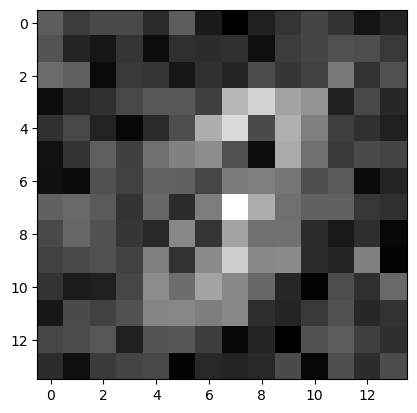

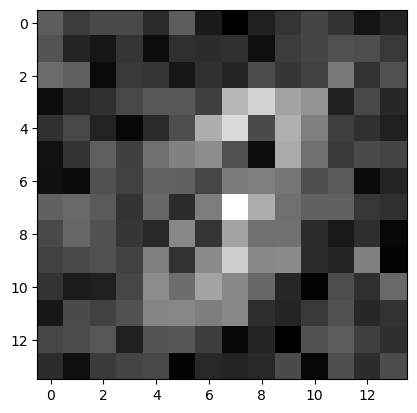

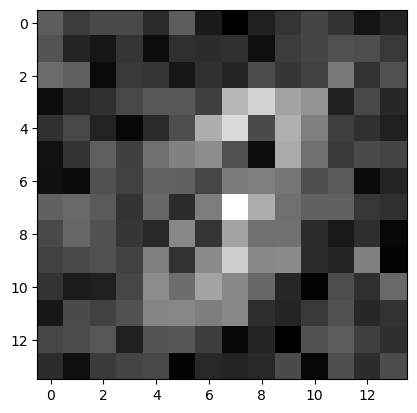

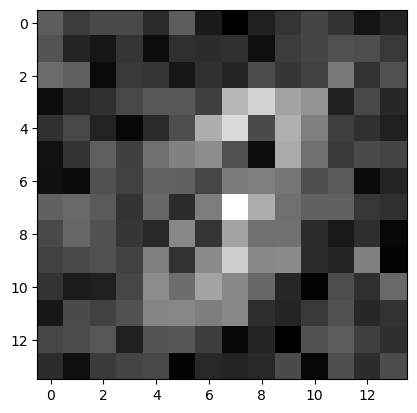

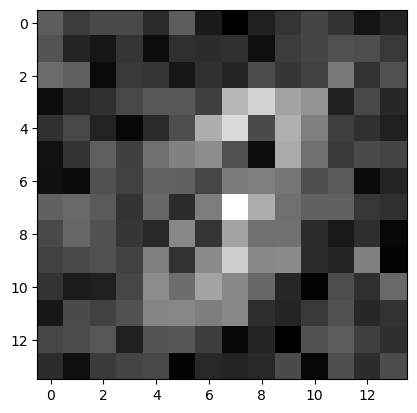

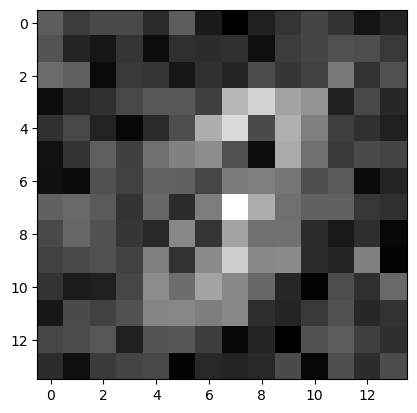

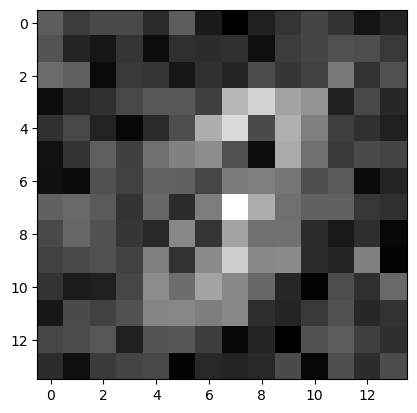

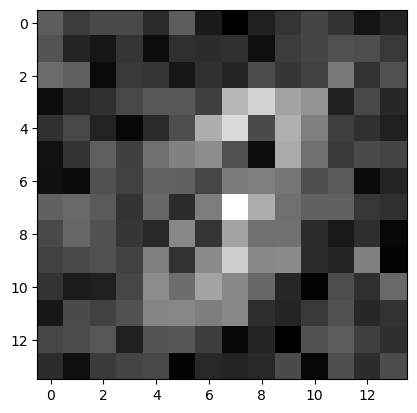

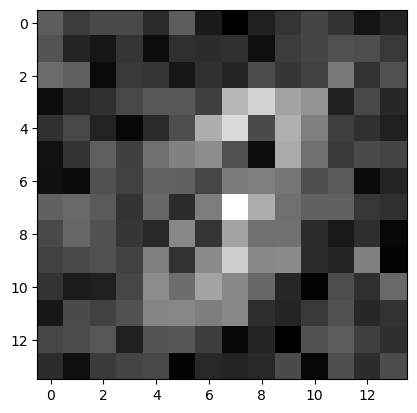

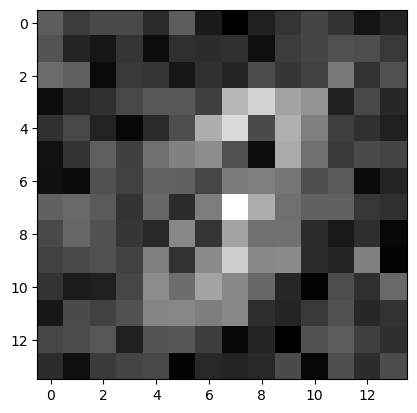

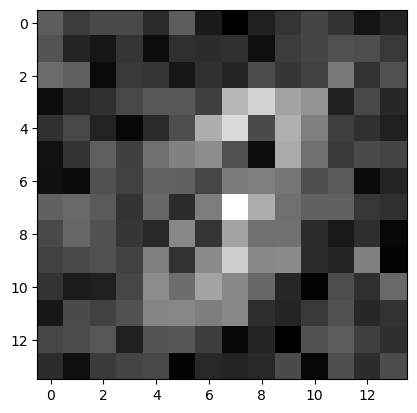

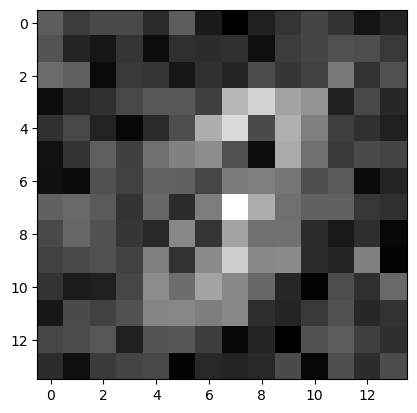

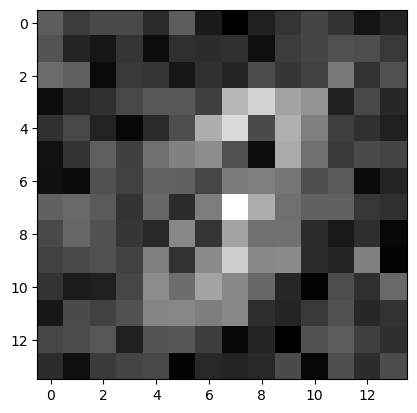

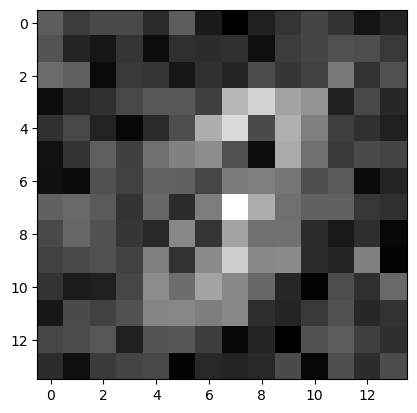

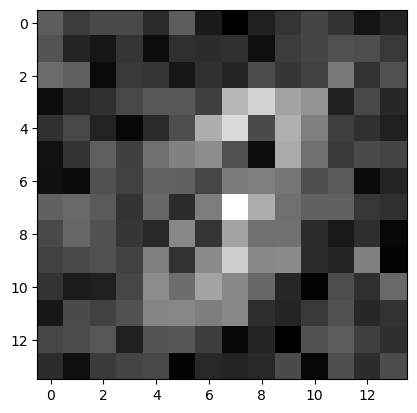

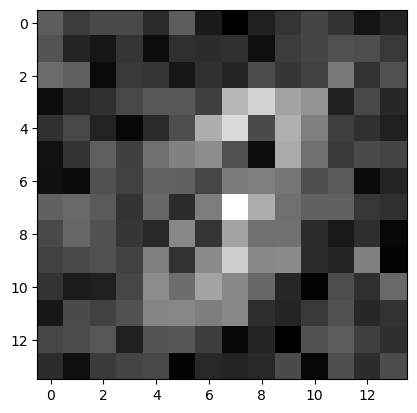

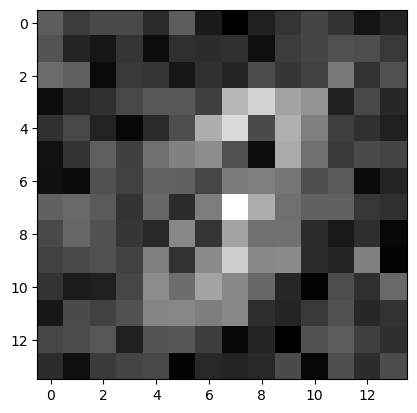

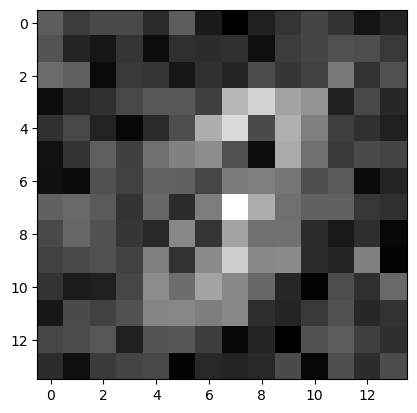

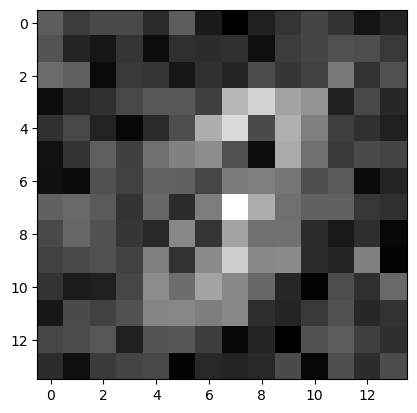

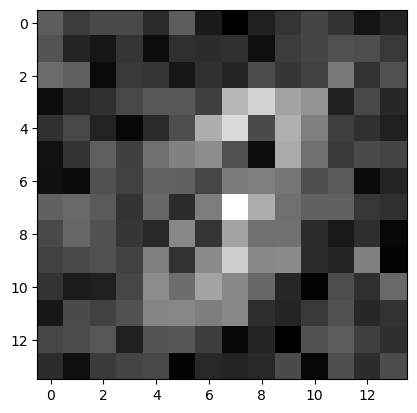

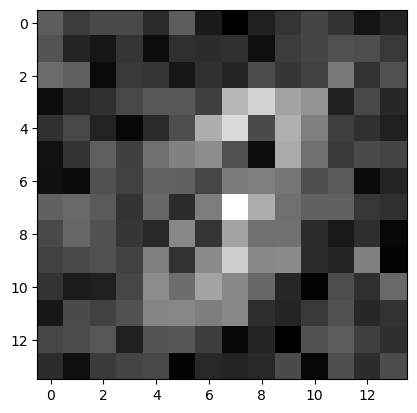

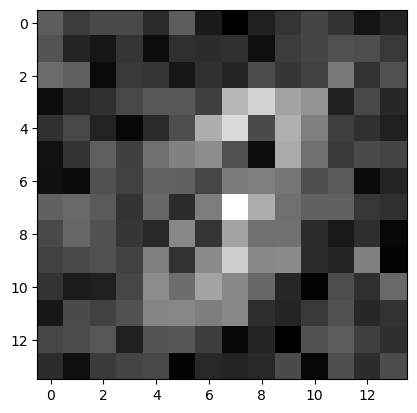

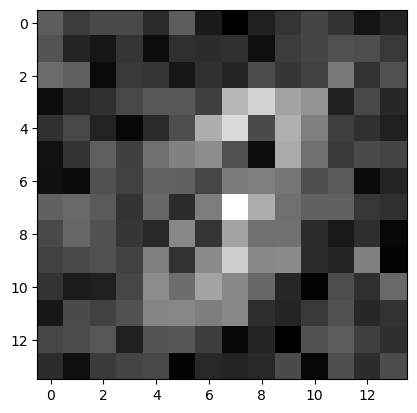

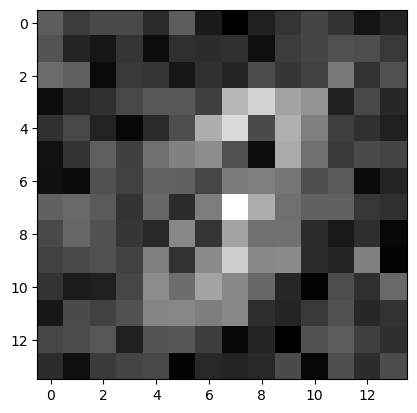

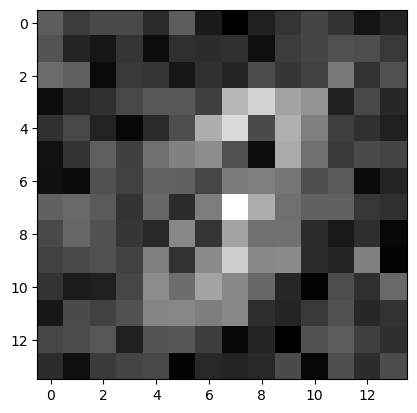

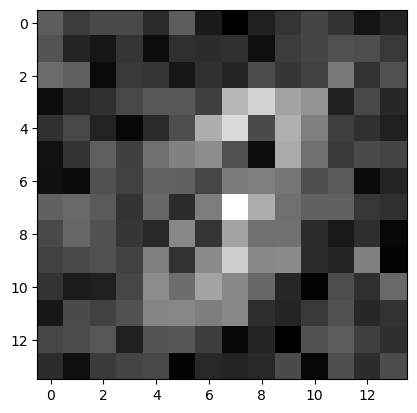

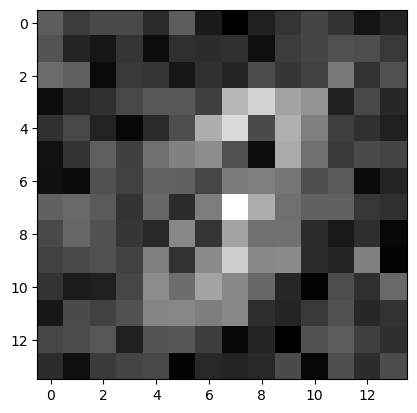

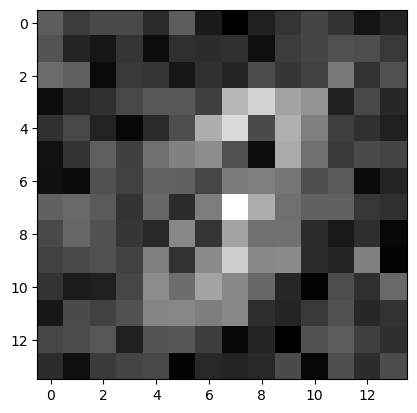

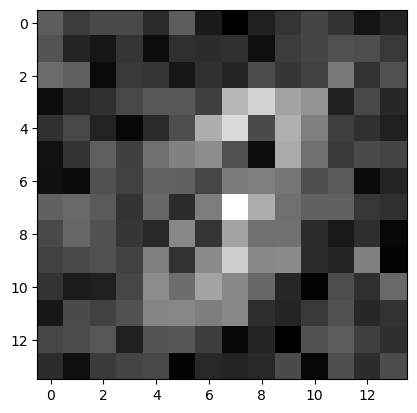

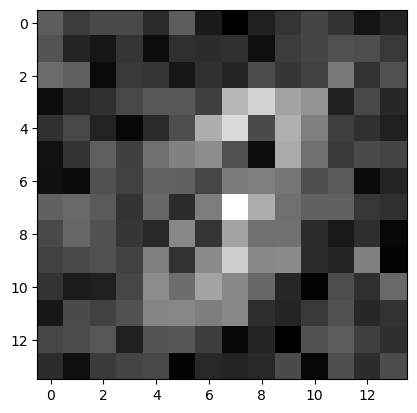

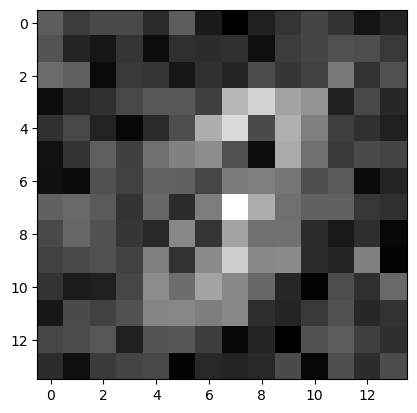

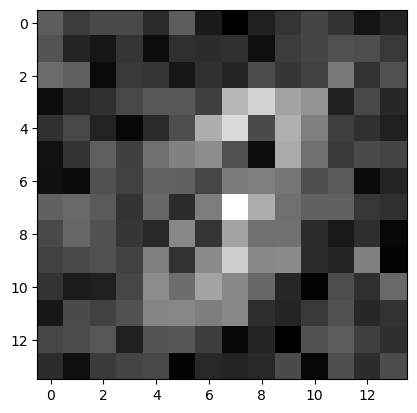

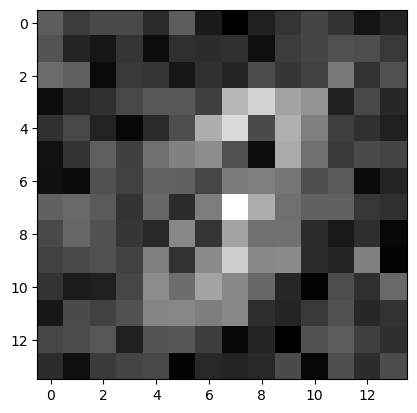

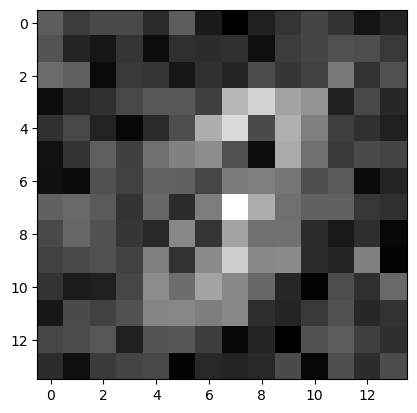

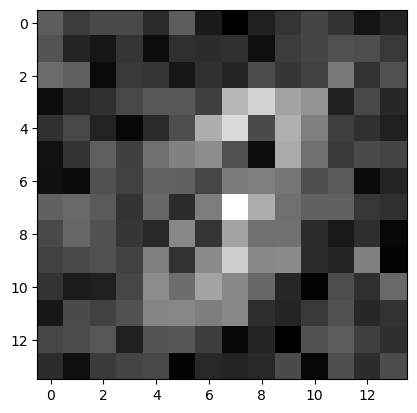

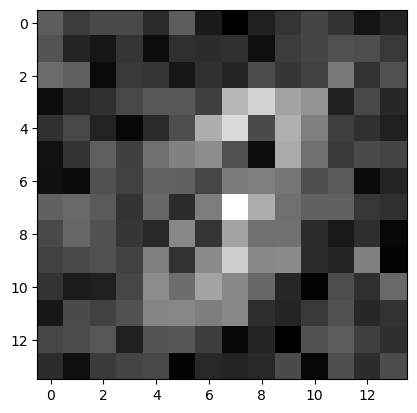

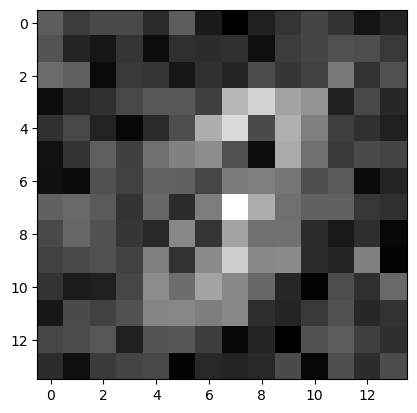

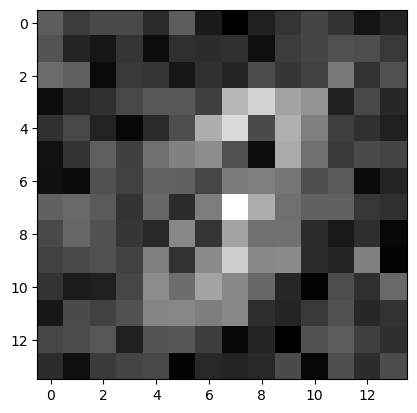

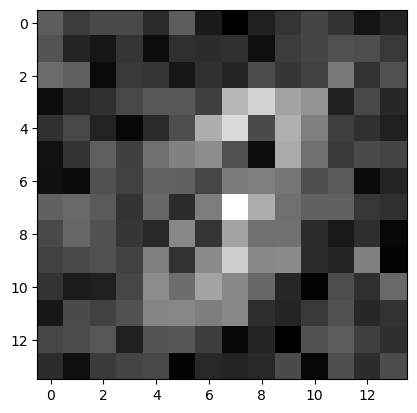

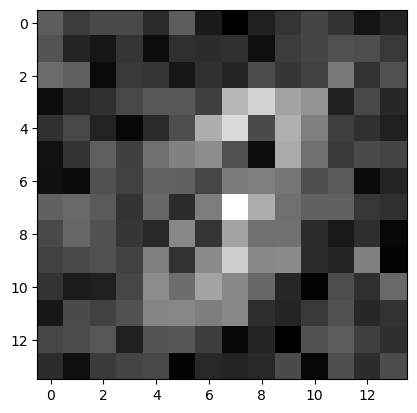

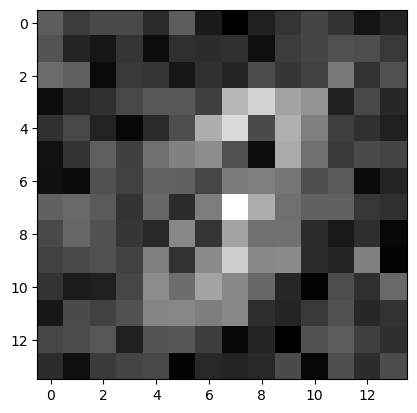

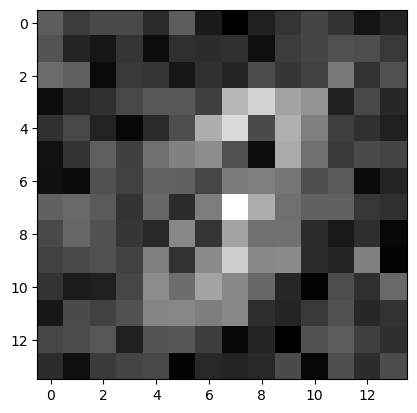

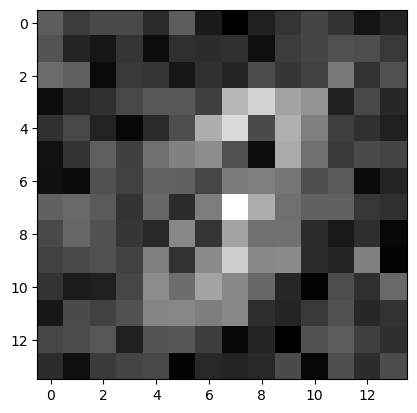

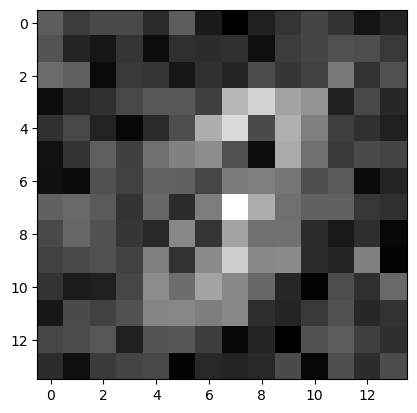

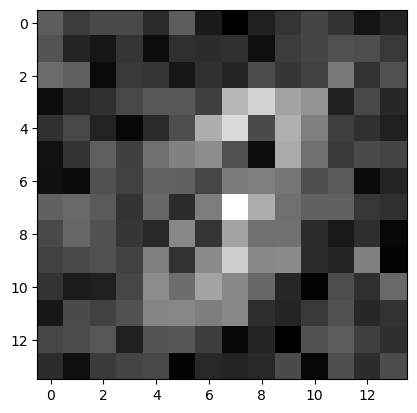

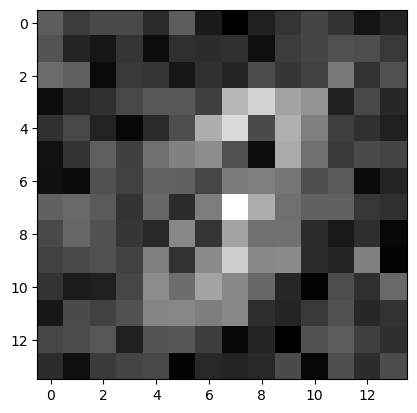

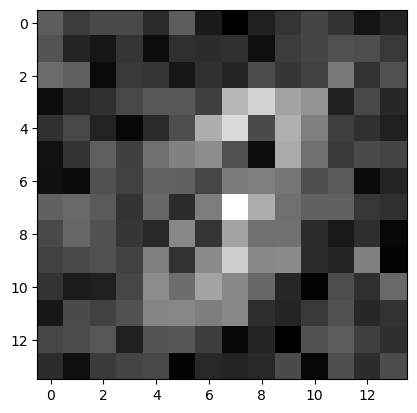

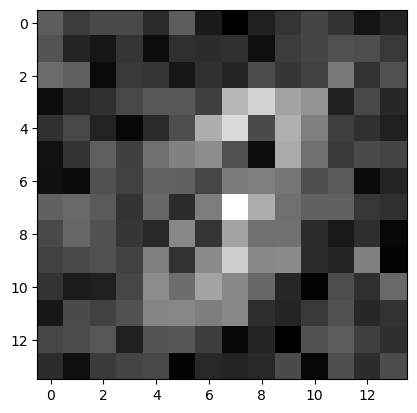

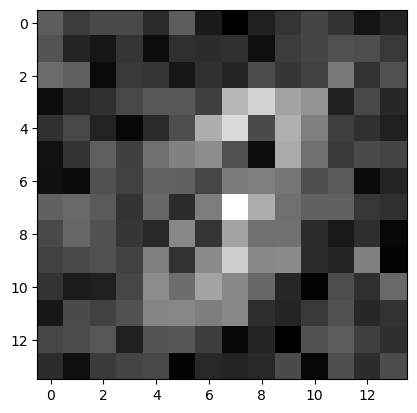

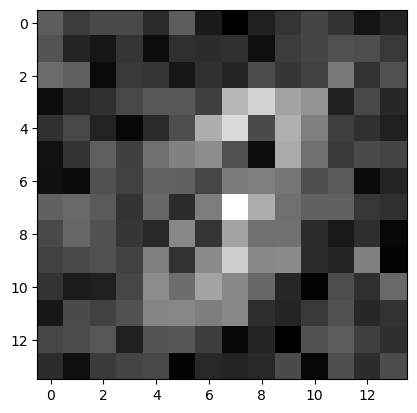

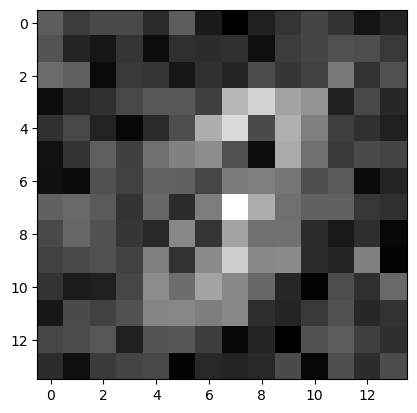

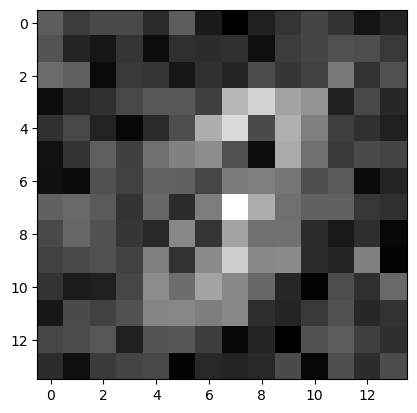

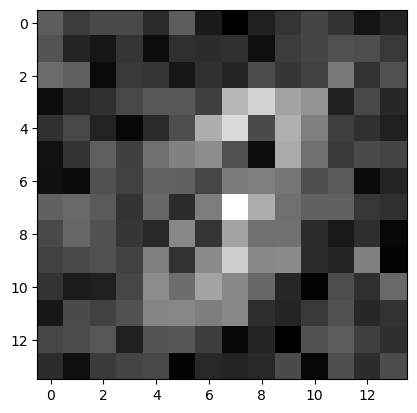

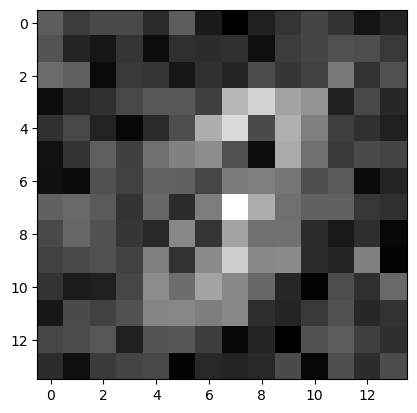

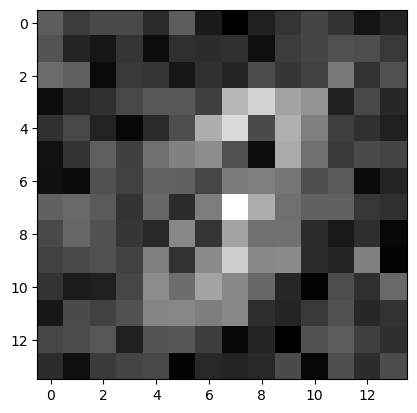

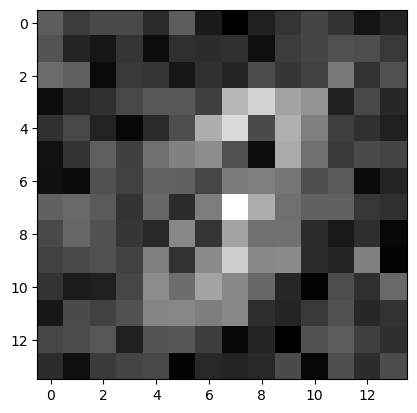

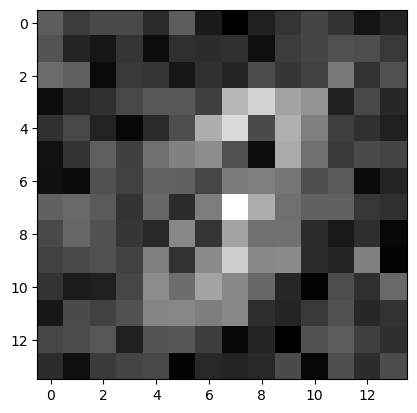

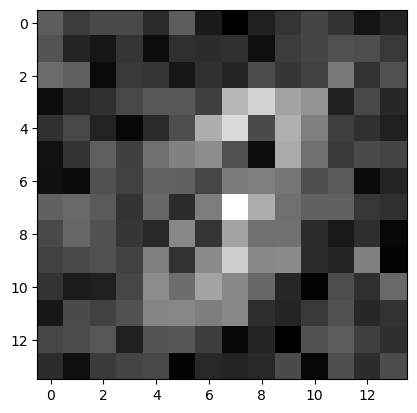

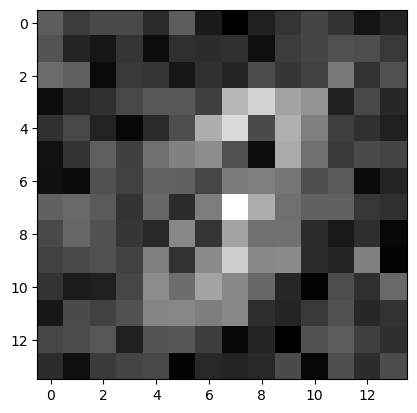

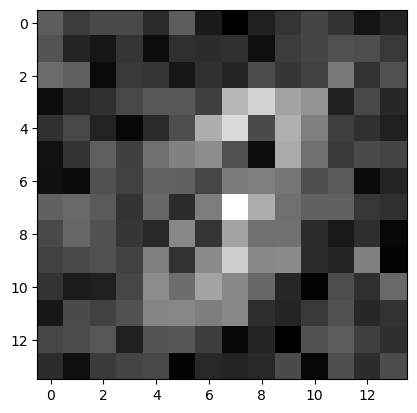

/tmp/ipykernel_188809/1660316540.py:17: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  I_vec_r = np.abs(I_vec)


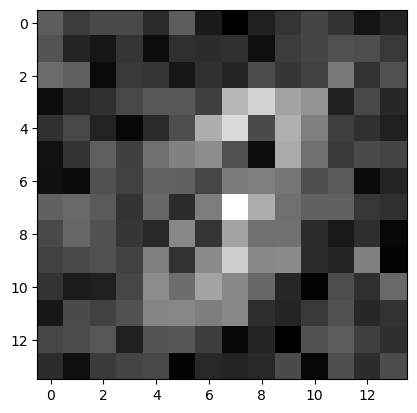

In [21]:
P_vec = P_space.normalize(P_space.init_random_vec() + P_vecs[:,0:1])
for i in range(100):
    I_vec = IP_map.backwards(P_vec)
    I_vec_r = np.abs(I_vec)
    mnist_image = show_image(I_vec_r.T[0])
    # Set the color mapping to grayscale to have a black background.
    plt.imshow(mnist_image, cmap="gray")
    # Display the image.
    plt.show()
    PM_vec = PM_map.norm_forwards_norm(P_vec)
    EM_vec = M_space.norm_unbind(M_bundle, PM_vec)
    E_vec = EM_map.norm_backwards_norm(EM_vec)
    EM_vec2 = EM_map.norm_forwards_norm(E_vec)
    PM_vec2 = M_space.norm_unbind(M_bundle, EM_vec2)
    P_vec = PM_map.norm_backwards_norm(PM_vec2)
I_vec = IP_map.backwards(P_vec)
I_vec_r = np.abs(I_vec)
mnist_image = show_image(I_vec_r.T[0])
# Set the color mapping to grayscale to have a black background.
plt.imshow(mnist_image, cmap="gray")
# Display the image.
plt.show()